In [123]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
from functions import print_traffic_for_days

In [124]:
df_features = pl.read_parquet("data/features.parquet")
df_cleaned = pl.read_parquet("data/cleaned.parquet")

In [125]:
df_features.head(3)

source.ip,3xx,2xx,5xx,4xx,active_days_ratio,request_count,endpoint_entropy,time_entropy
str,f64,f64,f64,f64,f64,u32,f64,f64
"""172.105.89.161""",1.0,0.0,0.0,0.0,0.714286,6,-0.0,2.584963
"""186.32.219.176""",1.0,0.0,0.0,0.0,0.142857,1,-0.0,-0.0
"""1.180.246.82""",1.0,0.0,0.0,0.0,0.142857,1,-0.0,-0.0


In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

def print_distribution(column_name: str, bins: int = 10):
    # Convert column to numpy array
    data = df_features[column_name].to_numpy()

    # Create figure with 2 rows, shared x-axis
    fig, axes = plt.subplots(2, 1, figsize=(12, 4), gridspec_kw={"height_ratios": [4, 1]}, sharex=True)

    # Histogram with KDE
    sns.histplot(data, bins=bins, kde=True, color="navy", ax=axes[0])
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"Distribution of {column_name.replace('_', ' ').title()} per IP")

    # Boxplot below
    sns.boxplot(x=data, color="skyblue", ax=axes[1])
    axes[1].set_xlabel(column_name.replace("_", " ").title())

    plt.tight_layout()
    plt.show()


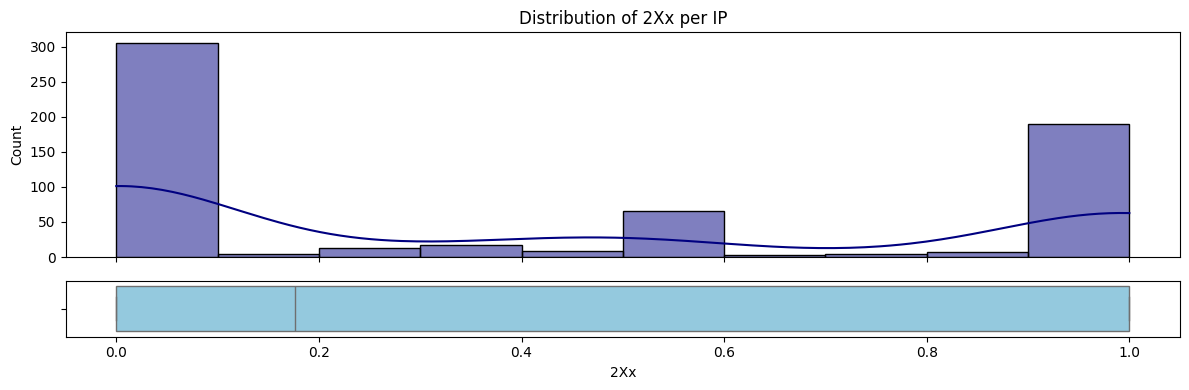

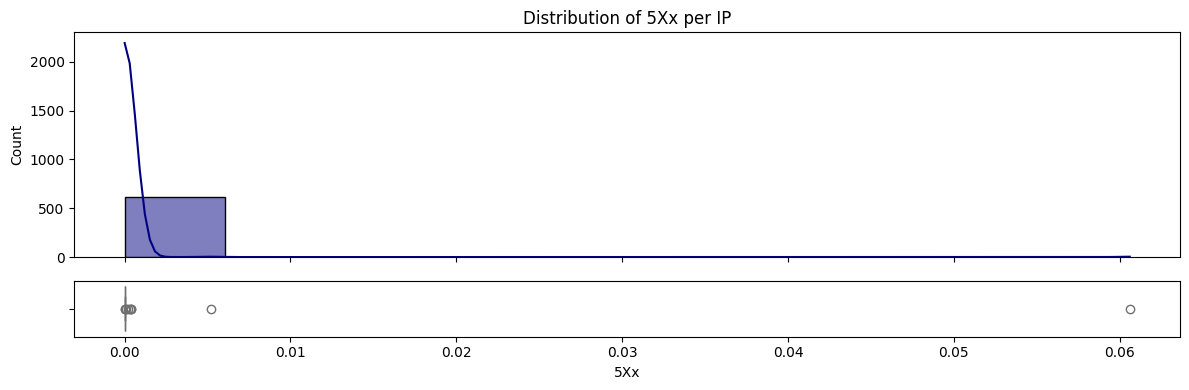

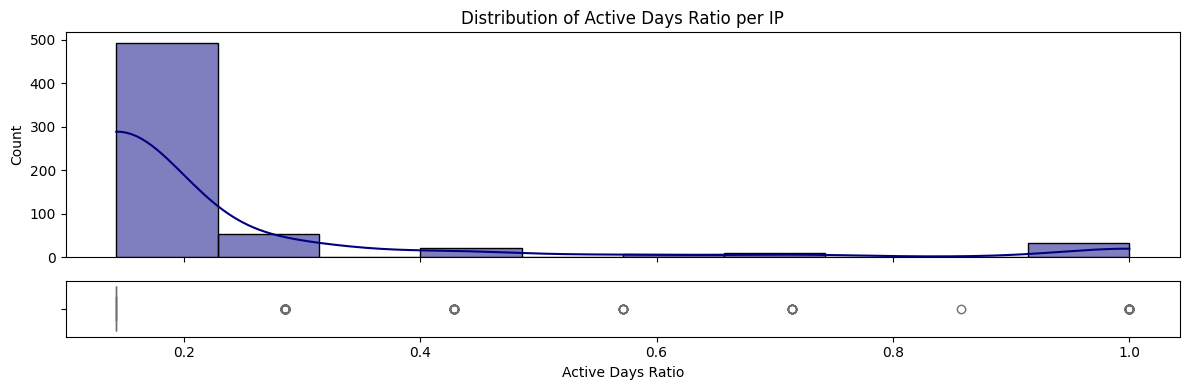

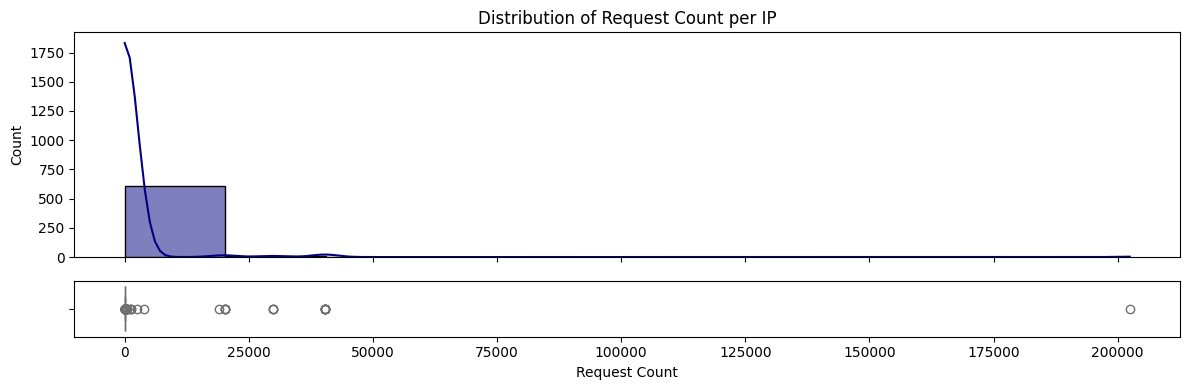

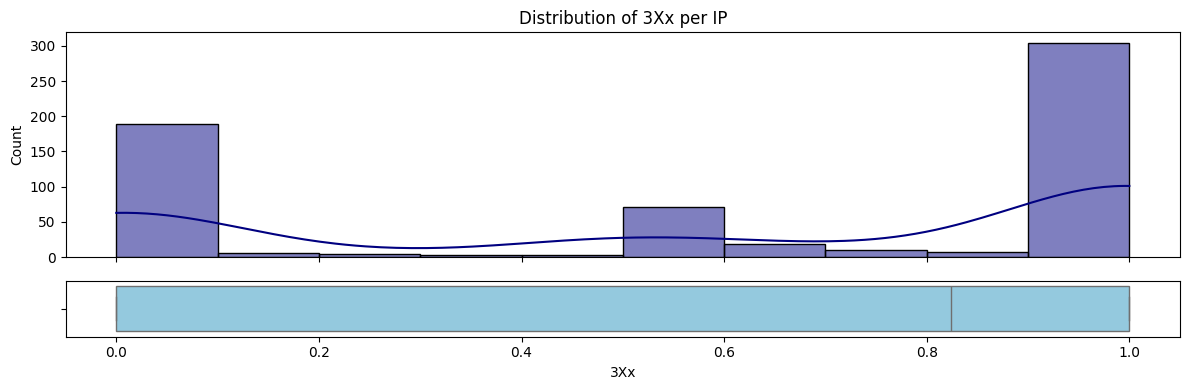

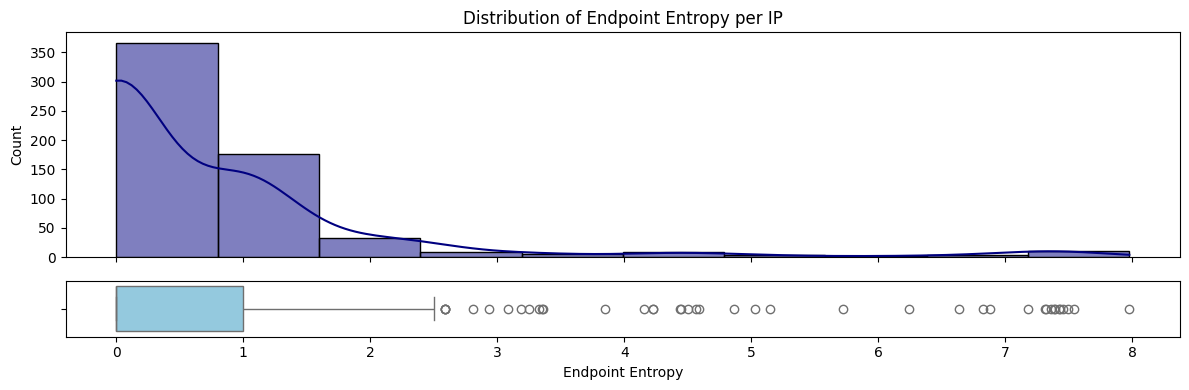

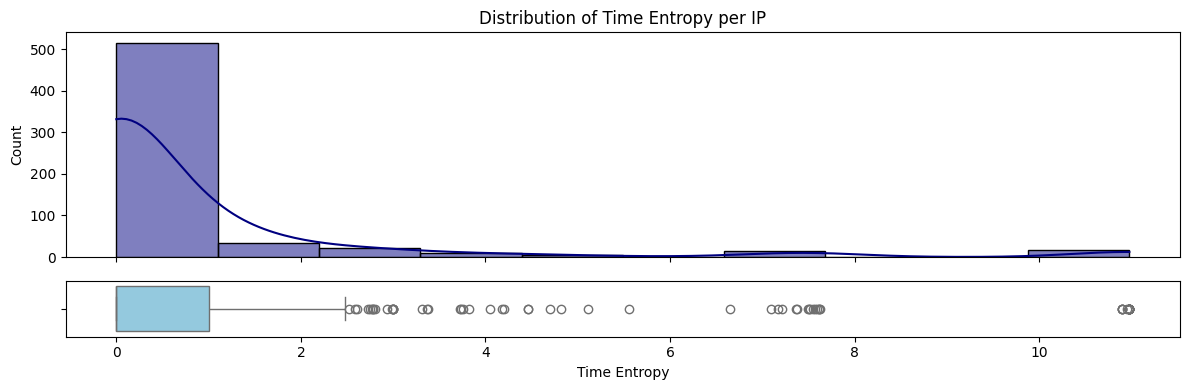

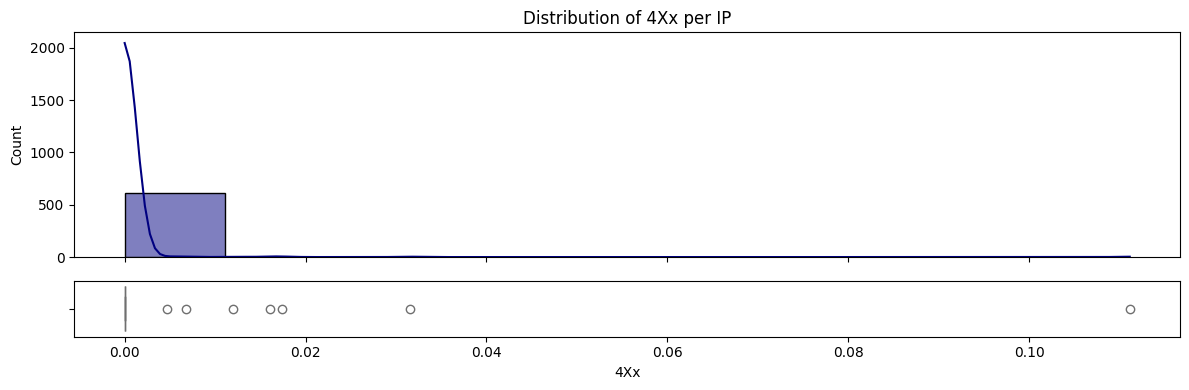

In [127]:
df_features_names = set(df_features.columns) - {"source.ip"}
for col in df_features_names:
    print_distribution(col, bins=10)

<Axes: xlabel='request_count'>

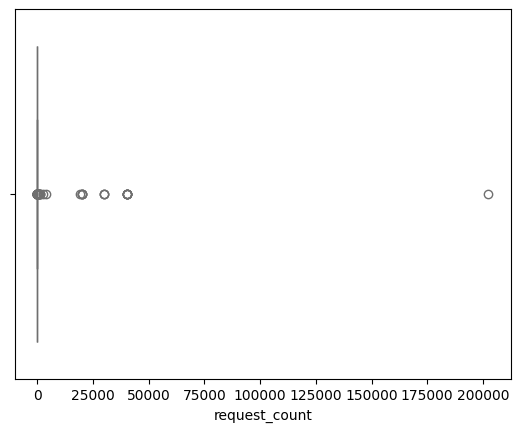

In [128]:
sns.boxplot(x=df_features["request_count"], color="skyblue")

In [187]:
# 1. Background Noise: Insignificant volume
background_noise_mask = (pl.col("request_count") < 5)

# 2. Targeted Attackers: High volume, focused target, high errors
targeted_attacker_mask = (
    (pl.col("request_count") >= 200) &
    (pl.col("endpoint_entropy") <= 0.5) &  # Focused on one or very few endpoints
    ((pl.col("4xx") + pl.col("5xx")) >= 0.1) # High failure rate
)

# 3. Scanners: Wide probing or high errors, low persistence
scanner_mask = (
    (pl.col("active_days_ratio") < 0.30) & # Transient
    (
        (pl.col("4xx") >= 0.1) |           # High client errors
        (pl.col("endpoint_entropy") >= 2.0) # Checking many distinct paths
    ) &
    (pl.col("request_count") >= 40) # Enough data to determine it's not just noise
)

# 4. Persistent Services: Highly reliable, automated, long-term
persistent_service_mask = (
    (pl.col("active_days_ratio") >= 0.7) &
    (pl.col("endpoint_entropy") <= 1.2) &
    (pl.col("time_entropy") <= 1.2) &
    ((pl.col("2xx") + pl.col("3xx")) >= 0.8) &
    (pl.col("request_count") >= 50)
)

# 5. Normal Users: Human-like randomness and browsing behavior
normal_user_mask = (
    (pl.col("time_entropy") > 1.2) &      # Irregular timing
    (pl.col("endpoint_entropy") > 1.2) &  # Varied endpoints
    ((pl.col("2xx") + pl.col("3xx")) >= 0.8) &
    (pl.col("request_count") >= 5) &
    (~persistent_service_mask) # Ensure no overlap with services
)

# Apply Logic in Priority Order
df_features = df_features.with_columns(
    pl.when(background_noise_mask).then(pl.lit("background_noise"))
      .when(targeted_attacker_mask).then(pl.lit("targeted_attacker"))
      .when(scanner_mask).then(pl.lit("scanner"))
      .when(persistent_service_mask).then(pl.lit("persistent_service"))
      .when(normal_user_mask).then(pl.lit("normal_user"))
      .otherwise(pl.lit("other"))
      .alias("behavior_label")
)

In [188]:
df_rule_classified = df_features.group_by("behavior_label").agg(
    pl.len().alias("count")
)
df_rule_classified

behavior_label,count
str,u32
"""background_noise""",479
"""normal_user""",44
"""scanner""",10
"""other""",84


In [189]:
scanners = df_features.filter(pl.col("behavior_label") == "scanner")

In [190]:
df_agg_sus = (
    df_cleaned
    .filter(pl.col("source.ip").is_in(scanners["source.ip"]))
    .group_by(
        pl.col("timestamp").dt.date().cast(pl.String).alias("day"),
        pl.col("timestamp").dt.truncate("5m").dt.time().alias("time_bin")
    )
    .len()  # Get the count of requests
    .sort("day", "time_bin") # Sort for a clean line plot
)

C:\Users\wojom\AppData\Local\Temp\ipykernel_14884\1897201585.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  .filter(pl.col("source.ip").is_in(scanners["source.ip"]))


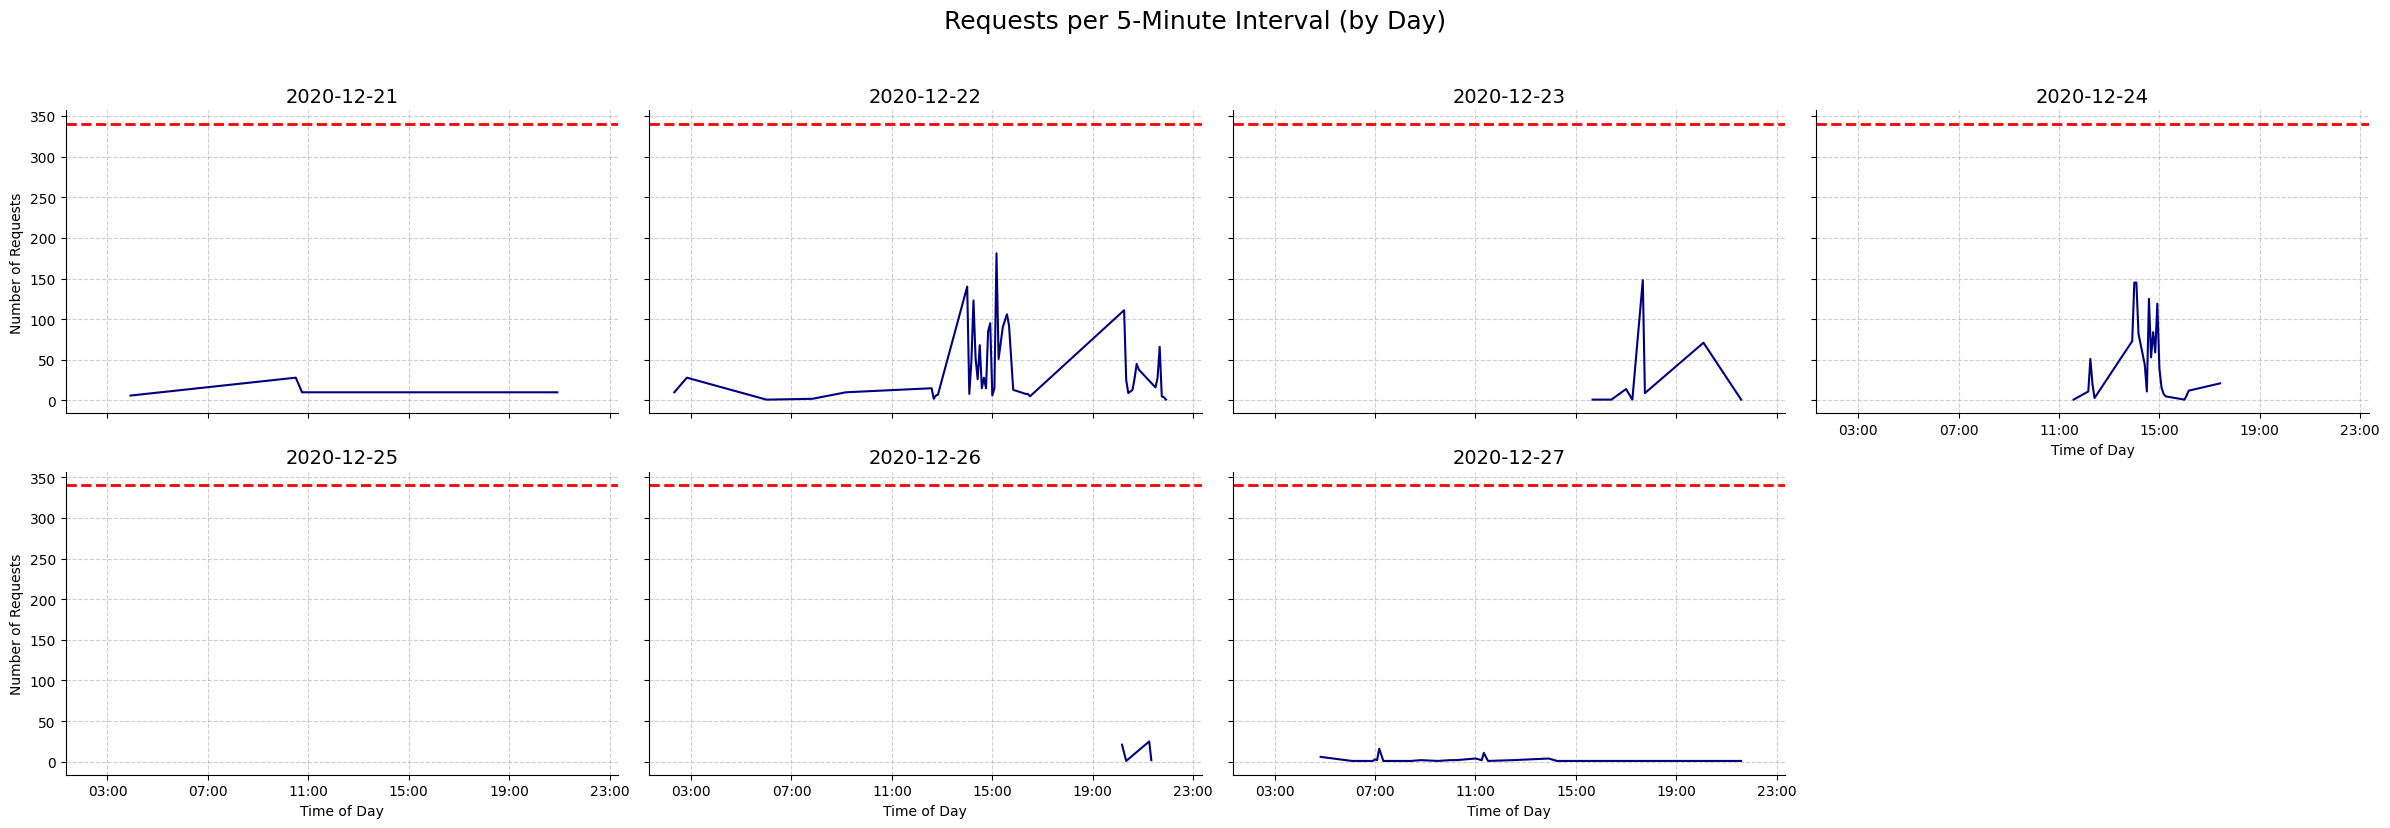

In [191]:
print_traffic_for_days(df_agg_sus)

In [192]:
df_features.write_parquet("data/rule_classified.parquet")